- Test the snapshot interpolation in forward simulation.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from pmwd import (
    Configuration,
    Cosmology, SimpleLCDM,
    boltzmann,
    white_noise, linear_modes,
    lpt,
    nbody,
    scatter,
    Particles,
)

import matplotlib.pyplot as plt

In [2]:
ptcl_spacing = 4.
ptcl_grid_shape = (64,) * 3
conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=1)
conf = conf.replace(a_snapshots=(conf.a_nbody[-2],
                                 (conf.a_nbody[-2] + conf.a_nbody[-1]) / 2,
                                 conf.a_nbody[-1]))

# print(conf)  # with other default parameters
print(f'Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')
print(f'nbody a step: {conf.a_nbody}')
print(f'observable snapshots a: {conf.a_snapshots}')

cosmo = SimpleLCDM(conf)
# print(cosmo)

cosmo = boltzmann(cosmo, conf)
seed = 0
modes = white_noise(seed, conf)
modes = linear_modes(modes, cosmo, conf)

ptcl, obsvbl = lpt(modes, cosmo, conf)
ptcl, obsvbl = nbody(ptcl, obsvbl, cosmo, conf)

Simulating 262144 particles with a (64, 64, 64) mesh for 63 time steps.
nbody a step: [0.016 0.031 0.047 0.062 0.078 0.094 0.109 0.125 0.141 0.156 0.172 0.188 0.203 0.219 0.234 0.25  0.266 0.281 0.297 0.312 0.328
 0.344 0.359 0.375 0.391 0.406 0.422 0.438 0.453 0.469 0.484 0.5   0.516 0.531 0.547 0.562 0.578 0.594 0.609 0.625 0.641 0.656
 0.672 0.688 0.703 0.719 0.734 0.75  0.766 0.781 0.797 0.812 0.828 0.844 0.859 0.875 0.891 0.906 0.922 0.938 0.953 0.969 0.984
 1.   ]
observable snapshots a: (Array(0.984, dtype=float64), Array(0.992, dtype=float64), Array(1., dtype=float64))


In [10]:
# check if the last snapshot in obsvbl agrees with ptcl
print(jnp.allclose(ptcl.disp, obsvbl['snaps'][2].disp))
print(jnp.allclose(ptcl.vel, obsvbl['snaps'][2].vel))

True
True


1.0
0.9991163


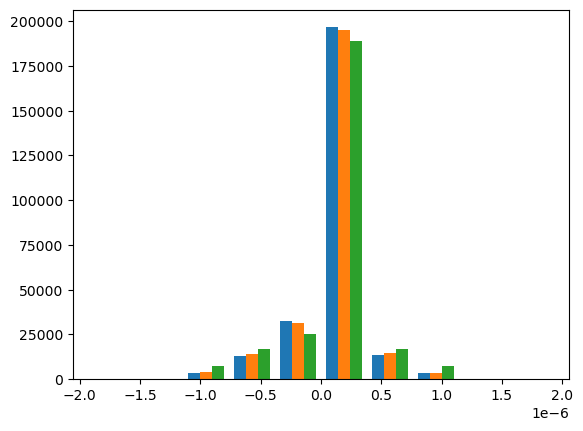

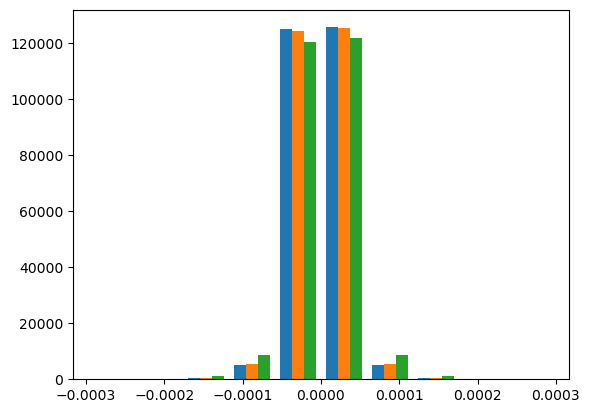

In [19]:
# check the interpolated snapshot between the last two steps
from pmwd.obs_util import interptcl, itp_prev, itp_next

a0, a1 = conf.a_nbody[-2], conf.a_nbody[-1]
a_itp = conf.a_snapshots[1]
ptcl0, ptcl1 = obsvbl['snaps'][0], obsvbl['snaps'][2]

iptcl = interptcl(ptcl0, ptcl1, a0, a1, a_itp, cosmo)

# disp0, vel0 = itp_prev(ptcl0, a0, a1, a_itp, cosmo)
# disp1, vel1 = itp_next(ptcl1, a0, a1, a_itp, cosmo)
# iptcl = Particles(ptcl0.conf, ptcl0.pmid, disp0 + disp1, vel=vel0 + vel1)

print(jnp.isclose(iptcl.disp, obsvbl['snaps'][1].disp).mean())
print(jnp.isclose(iptcl.vel, obsvbl['snaps'][1].vel, rtol=1e-4, atol=1e-5).mean())

plt.hist(iptcl.disp - obsvbl['snaps'][1].disp); plt.show()
plt.hist(iptcl.vel - obsvbl['snaps'][1].vel); plt.show()